# 🌌 Gravitational Wave Data Analysis: Open Data Workshop 2026

This repository contains the code and methodology to solve the Open Data Workshop 2026 Data Challenge. The main goal of this project is the identification, filtering, and parameter estimation of gravitational wave signals from binary black hole (BBH) coalescences, injected into both simulated Gaussian noise and real data from the LIGO detector.

## 🛠️ Tools and Technologies

The analysis is implemented in **Python** and uses standard libraries in computational astrophysics research:
* **`gwpy`**: For general time-series handling and visualization in the time-frequency space (Q-Transforms).
* **`PyCBC`**: For theoretical waveform generation (post-Newtonian approximation), Power Spectral Density (PSD) estimation, and Matched Filtering application.
* **`Bilby`**: For Bayesian parameter estimation (chirp mass inference and confidence intervals).

## 📂 Challenge Structure

The project is divided into four phases of increasing complexity:

1. **Challenge 1 (Novice):** Visual identification of the merger time of a loud BBH signal hidden in white Gaussian noise using the Q-Transform.
2. **Challenge 2 (Rookie):** Extraction of a signal in colored Gaussian noise. Involves generating an `SEOBNRv4_opt` template and implementing a matched filter to find the Signal-to-Noise Ratio (SNR) peak.
3. **Challenge 3 (Intermediate):** Search for a loud event ($m_1 = m_2 = 10 M_{\odot}$) in real data from the LIGO interferometer, applying the same filtering techniques on real instrumental noise.
4. **Challenge 4 (Advanced):** Blind search and parameter estimation in coincident data from the H1 and L1 interferometers. Includes discriminating astrophysical signals from instrumental glitches and using MCMC/Nested sampling with `bilby` to find the posterior distribution of the masses.

## 📥 Getting the Data

The data files (`.gwf`) are not included in this repository. 
To run the code, you must download the following files and place them in a `Data/` folder:

* [challenge1.gwf](https://dcc.ligo.org/public/0187/G2300818/001/challenge1.gwf)
* [challenge2.gwf](https://dcc.ligo.org/public/0187/G2300818/001/challenge2.gwf)
* [challenge3.gwf](https://dcc.ligo.org/public/0187/G2300818/001/challenge3.gwf)

In [1]:
# --- Setup and Library Imports ---

# Suppress non-critical warnings
import warnings 
warnings.filterwarnings("ignore", "Wswiglal-redir-stdio")

# Standard numerical and plotting libraries
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# Core TimeSeries object from GWpy for data handling
from gwpy.timeseries import TimeSeries

#
from scipy.signal import find_peaks

# Specialized PyCBC modules for Gravitational Wave analysis
import pycbc
from pycbc.catalog import Merger
from pycbc import frame
from pycbc import psd
from pycbc.frame import read_frame
from pycbc.filter import matched_filter, resample_to_delta_t, highpass
from pycbc.waveform import get_td_waveform
from pycbc.psd import interpolate, inverse_spectrum_truncation

# Bayesian inference library for parameter estimation 
import bilby

* Now we define the files, channels and time interval we're going to use in the challenges.

In [2]:
# --- Data Configuration ---

# Define the paths for the GWF data files provided in the workshop
# Note: challenge3.gwf is listed twice to accommodate both H1 and L1 interferometer channels
files = [
    'Data/challenge1.gwf', 
    'Data/challenge2.gwf', 
    'Data/challenge3.gwf', 
    'Data/challenge3.gwf'
]

# Map each file to its corresponding channel name
channels = [
    'H1:CHALLENGE1', 
    'H1:CHALLENGE2', 
    'H1:CHALLENGE3', 
    'L1:CHALLENGE3'
]

# --- Global Time Parameters ---
start = 0
end = start + 128 # The data files typically contain 128-second segments

# 🚀 Challenge 1: Detecting a Binary Black Hole Signal

We aim to identify a **loud binary black hole signal** embedded in **white Gaussian noise**.  

The dataset is provided in the file `challenge1.gwf`.

---

## 🧠 Objective

To reveal the signal, we will:

1. Load the data into memory  
2. Compute and plot its **Q-transform**

---

## 🔍 What to look for

The gravitational wave signal appears as a **chirp** in the Q-transform plot — a characteristic pattern where the frequency increases over time. <br> The chirp should stand out clearly despite the noise, since the signal is relatively loud.

--- Information for H1:CHALLENGE1 ---
Sampling rate: 4096.0 Hz
Duration: 128.0 seconds



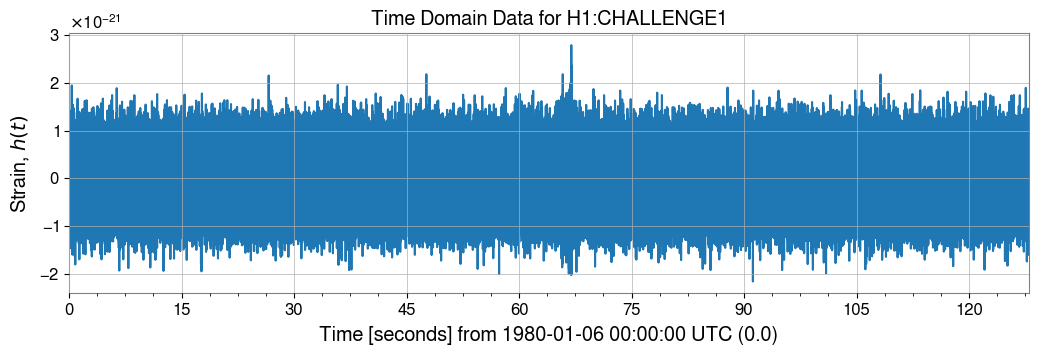

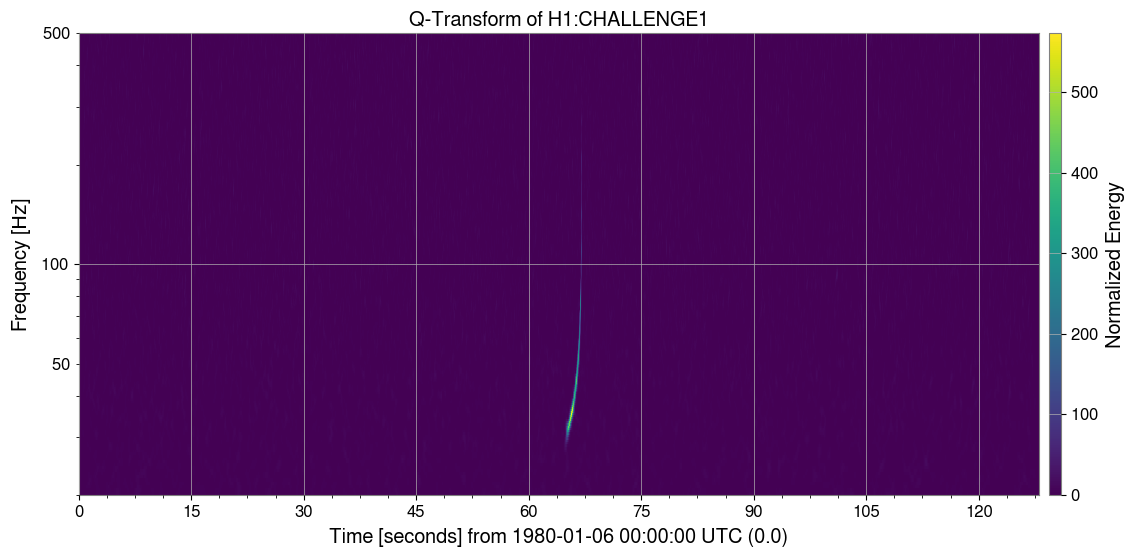

--- Information for H1:CHALLENGE2 ---
Sampling rate: 4096.0 Hz
Duration: 128.0 seconds



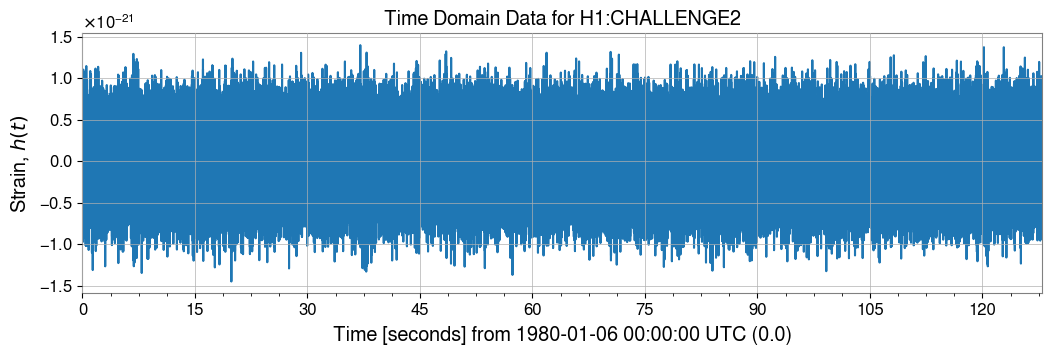

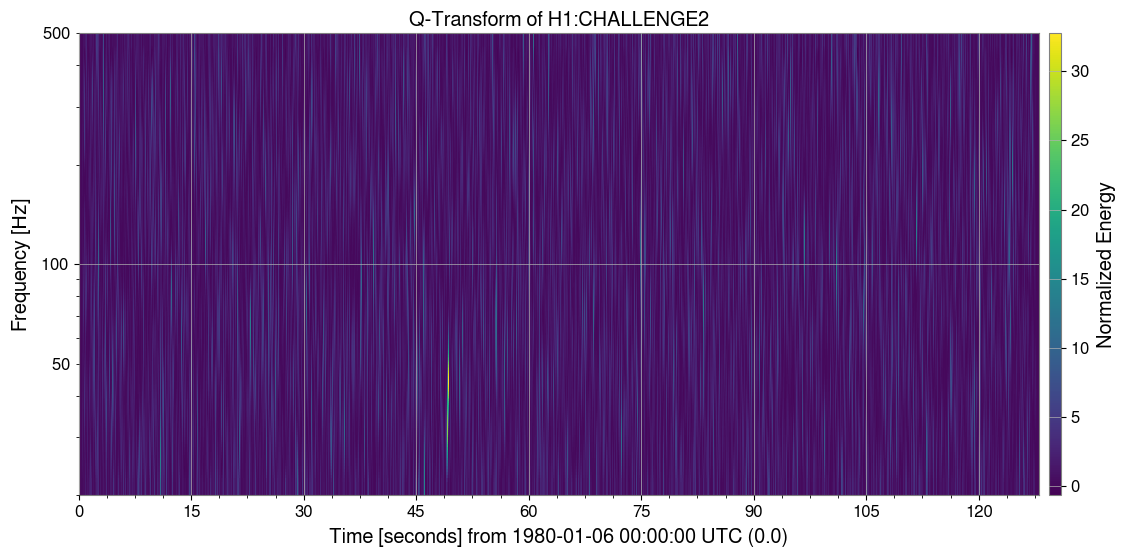

--- Information for H1:CHALLENGE3 ---
Sampling rate: 4096.0 Hz
Duration: 4096.0 seconds



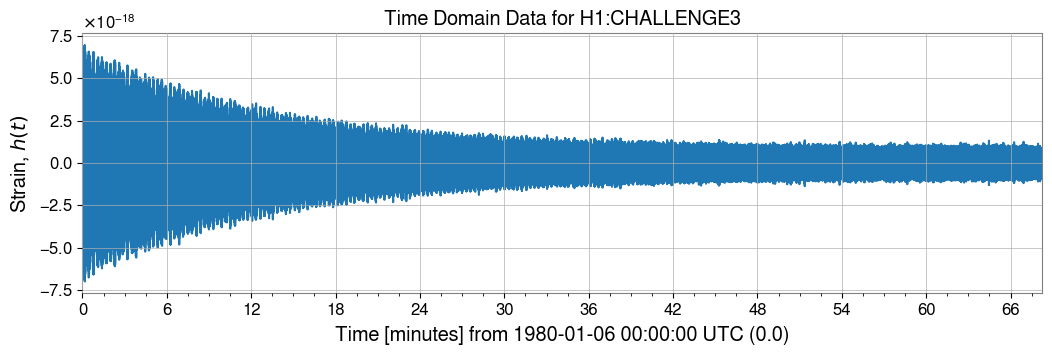

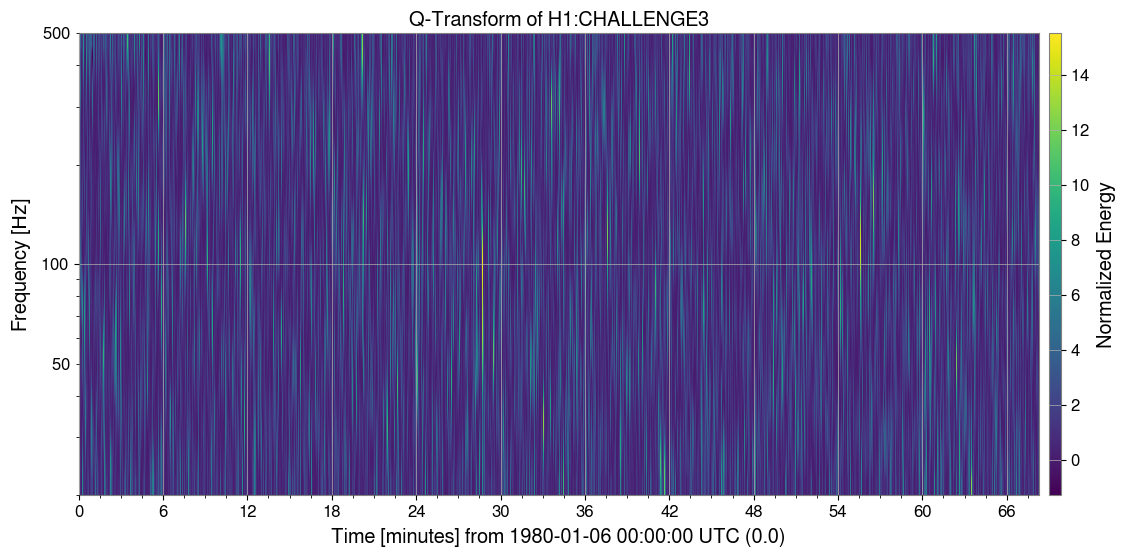

--- Information for L1:CHALLENGE3 ---
Sampling rate: 4096.0 Hz
Duration: 4096.0 seconds



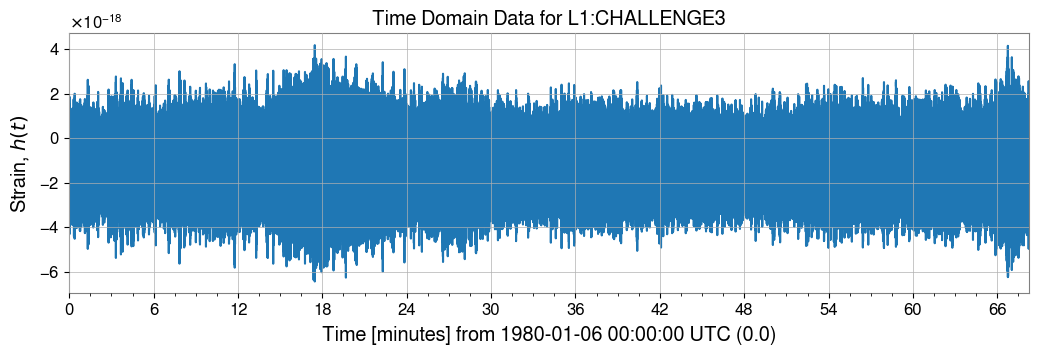

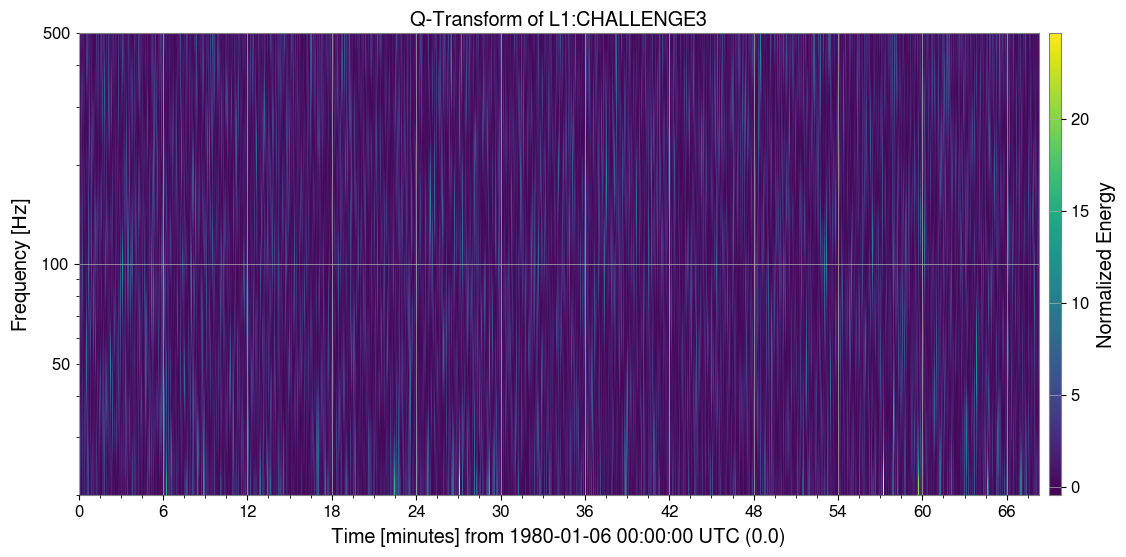

All data successfully stored in the 'gw_data' dictionary.


In [3]:
# Initialize an empty dictionary to store the TimeSeries objects
gw_data = {}

# Iterate over the files and channels simultaneously using zip() to ensure correct mapping
for fname, channel in zip(files, channels):
    
    # Load the gravitational wave strain data into memory using GWpy
    data = TimeSeries.read(fname, channel=channel)
    gw_data[channel] = data # Store the TimeSeries object for subsequent analysis stages
    
    # Extract fundamental data: sampling rate (Hz) and total duration (seconds)
    data_sr = data.sample_rate.value 
    data_duration = data.duration.value
    
    print(f"--- Information for {channel} ---")
    print(f"Sampling rate: {data_sr} Hz")       # Metadata required for Challenge 1
    print(f"Duration: {data_duration} seconds\n") # Metadata required for Challenge 1

    channel_clean = channel.replace(':', '_')
    
    # --- Time-Domain Visualization ---
    # Plot the raw strain data h(t) to inspect for obvious features or noise characteristics
    fig_time = data.plot()
    plt.title(f'Time Domain Data for {channel}')
    plt.ylabel(f'Strain, $h(t)$') 
    plt.show()
    
    # --- Time-Frequency Analysis (Q-Transform) ---
    # Perform a Q-transform to identify transient signals (chirps) within the noise
    # frange defines the frequency bounds (Hz), and qrange determines the quality factor resolution
    q_transform = data.q_transform(frange=(20, 500), qrange=(4, 64))

    fig_q = q_transform.plot()
    ax = fig_q.gca()
    ax.set_epoch(data.t0.value)  # Align the x-axis with the GPS start time of the segment
    ax.set_yscale('log')         # Use a logarithmic scale for frequency visualization
    ax.colorbar(label='Normalized Energy')
    plt.title(f'Q-Transform of {channel}')
    fig_q.savefig(f'images/{channel_clean}_qtransform.png', dpi=150, bbox_inches='tight')
    plt.show()

print("All data successfully stored in the 'gw_data' dictionary.")

In [4]:
# Access the specific time series data for Challenge 1
H1C1 = gw_data['H1:CHALLENGE1'] 

# Find the index of the maximum absolute strain amplitude: this peak marks the merger event
Tidx = H1C1.abs().argmax() 

# Calculate the time of the merger relative to the start of the data segment
merge_time = H1C1.times[Tidx].value - H1C1.t0.value 
print(f"The time of the merger H1:CHALLENGE1 (in seconds from the start of the segment): ", merge_time)

The time of the merger H1:CHALLENGE1 (in seconds from the start of the segment):  66.966552734375


## 🔎 Observations

The only clearly visible **chirp** appears in `H1:CHALLENGE1`.  

However, there are hints of a possible chirp in `H1:CHALLENGE2` around **49 seconds**, although it is not as prominent.

---

## ⚙️ Next Step

To enhance the visibility of potential signals, we will **adjust the parameters of the Q-transform**.

# 🚀 Challenge 2: Signal in Colored Gaussian Noise

We now aim to identify a **binary black hole (BBH) signal** embedded in **colored Gaussian noise**.  

The dataset is provided in the file `challenge2.gwf`, using the channel `H1:CHALLENGE2`.

The signal corresponds to a system with:
- $m_1 = m_2 = 30 \, M_\odot$
- **Zero spin**

---

## 🧠 Objective

To extract and characterize the signal, we will:

1. Plot a **Q-transform** of the data  
2. Generate a **time-domain template waveform** (using *SEOBNRv4_opt*) with the given parameters  
3. Compute and plot the **Power Spectral Density (PSD)** on a log-log scale (from 20 Hz to the Nyquist frequency)  
4. Use the template and PSD to calculate the **SNR time series**, and plot it  

---

## 🔍 What to look for

- The **chirp signal** should be visible in the Q-transform, although less clearly than in white noise  
- The **SNR time series** should show a clear peak at the time of the merger  

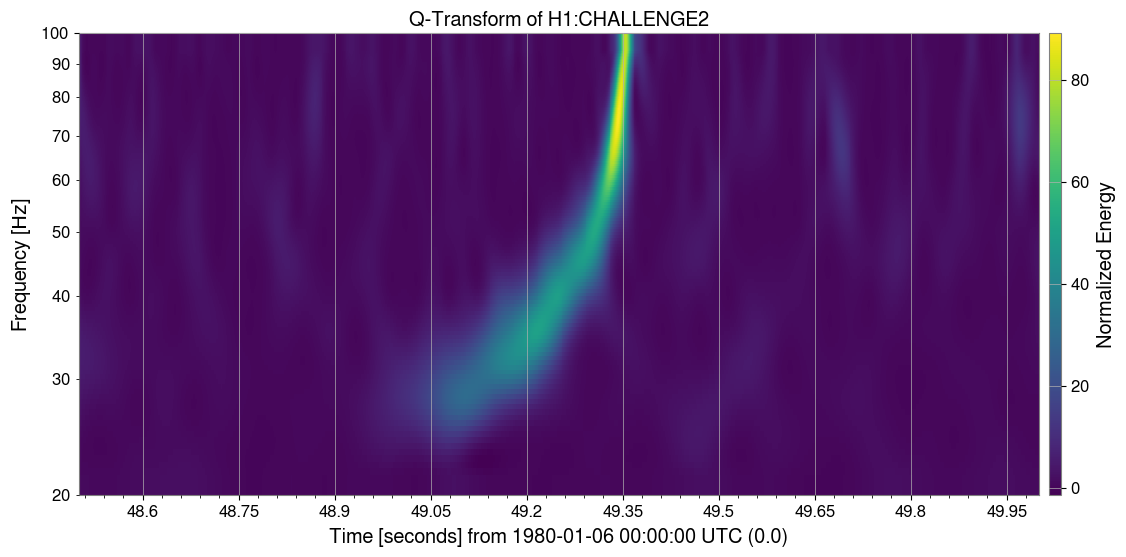

In [5]:
# Access the time series data for the second challenge
H1C2 = gw_data['H1:CHALLENGE2']

# Define an initial time estimate (seconds) for the chirp based on visual inspection in Challenge 1
guess = 49 

# Compute the Q-transform focusing on a narrow time window around the guess (outseg)
# We use frange=(20,100) based on Challenge 1 too, and in the values given for the masses (30 solar masses)
q_transform = H1C2.q_transform(frange=(20,100), qrange=(4,10), outseg=(guess-0.5, guess+1))

# --- Visualization ---
fig_q = q_transform.plot()
ax = fig_q.gca()
ax.set_epoch(H1C2.t0.value) # reference epoch to the data start time for relative timing
# Use a logarithmic scale for the frequency axis to better resolve the inspiral
ax.set_yscale('log')
ax.colorbar(label='Normalized Energy')
plt.title(f'Q-Transform of H1:CHALLENGE2')
plt.show()

## 🔎 Observations

The approximate time of the merger is:

\begin{equation}
T_{\text{merger}} \approx 49.35 \, \text{s}
\end{equation}
---
## ⚙️ Next Step

We can now generate a **time-domain template waveform** using the approximate model **SEOBNRv4\_opt**, with the parameters specified for this system.

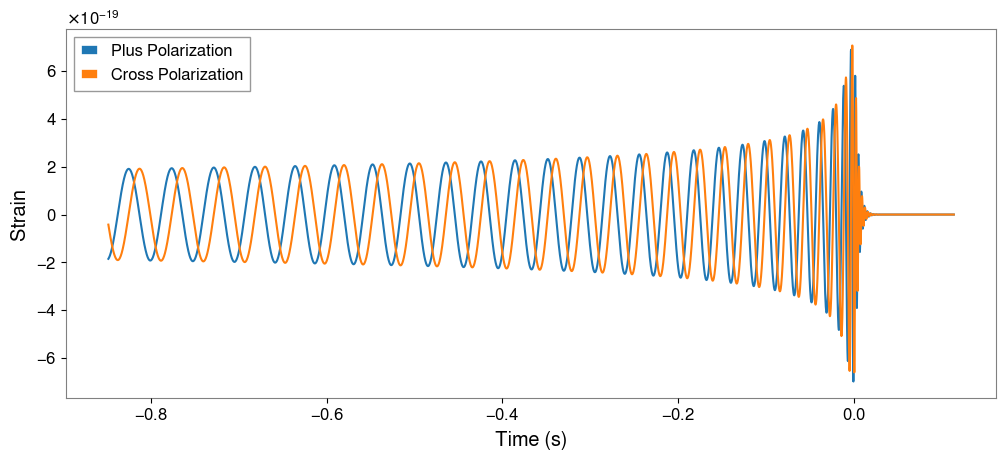

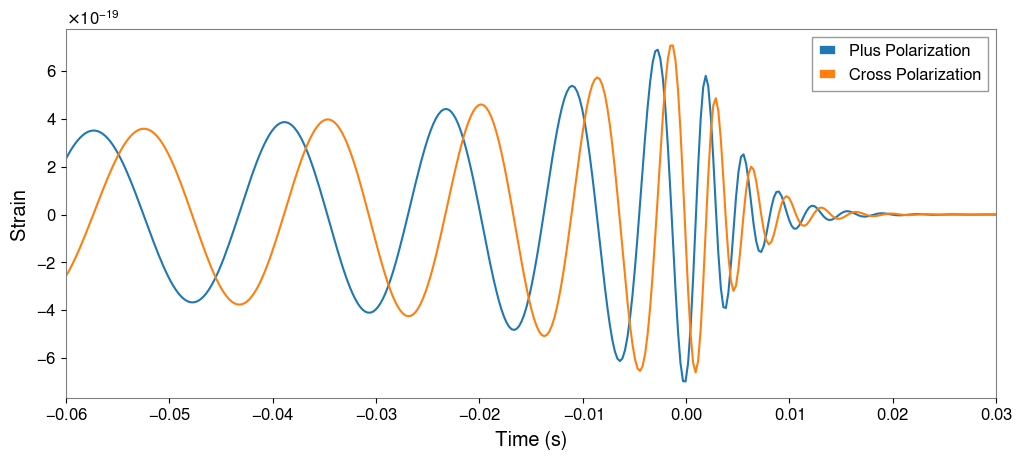

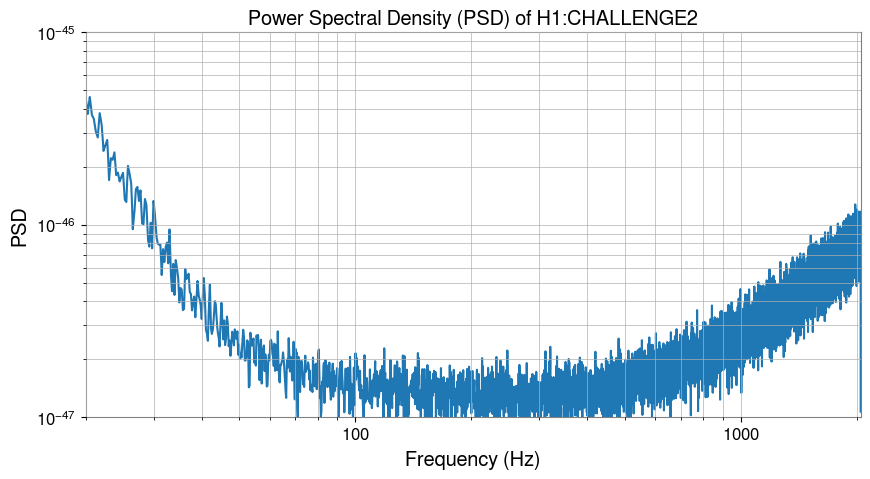

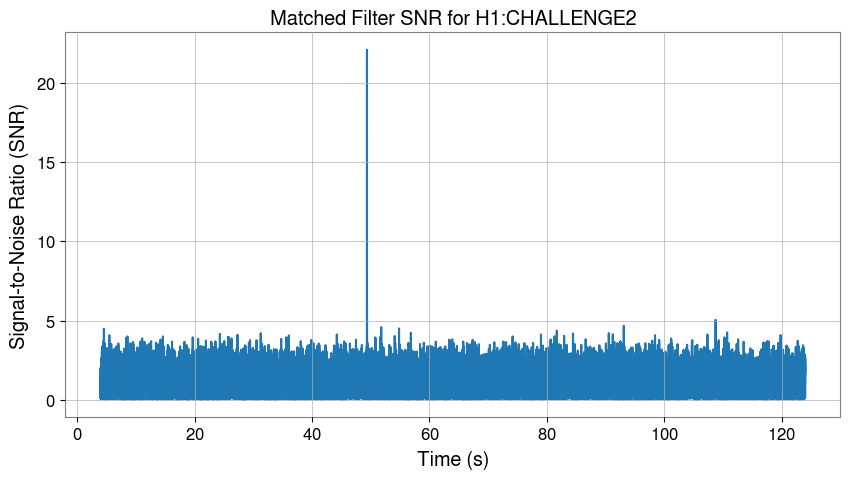

The peak SNR is: 22.08 at time 49.37 seconds.


In [6]:
# We access the channel H1:CHALLENGE2 from the specific GWF file
H1C2 = frame.read_frame(files[1], channels[1])

# Define the physical parameters for the binary black hole (BBH) signal
m1 = 30  # Component mass 1 in solar masses
m2 = m1  # Equal mass binary system
spin = 0 # Non-spinning black holes
delta_t = H1C2.delta_t # Match the template's time step to the data

# --- Generate a time-domain template using the SEOBNRv4_opt approximant ---
hp, hc = get_td_waveform(approximant='SEOBNRv4_opt',
                         mass1=m1, 
                         mass2=m2, 
                         spin1z=spin, 
                         spin2z=spin,
                         delta_t=delta_t,
                         f_lower=20
                        )
# --- Generated waveform template visualization ---
plt.figure(figsize=plt.figaspect(0.4))
plt.plot(hp.sample_times, hp, label='Plus Polarization')
plt.plot(hc.sample_times, hc, label='Cross Polarization')
plt.xlabel('Time (s)')
plt.ylabel('Strain')
plt.legend()
plt.grid()
# Zoom in near the merger time
plt.figure(figsize=plt.figaspect(0.4))
plt.plot(hp.sample_times, hp, label='Plus Polarization')
plt.plot(hc.sample_times, hc, label='Cross Polarization')
plt.xlabel('Time (s)')
plt.ylabel('Strain')
plt.xlim(-.06, .03) # Focus around the merger
plt.legend()
plt.grid()

# Resize the template to match the data length (zero-padding)
hp.resize(len(H1C2))

# --- Perform a cyclic time shift to align the merger time (t=0) with the start of the array ---
template = hp.cyclic_time_shift(hp.start_time)
# Use Welch's method with 4-second segments to characterize the colored noise
seg_len = int(4 / delta_t)
seg_stride = int(seg_len / 2)
psd = pycbc.psd.welch(H1C2, seg_len=seg_len, seg_stride=seg_stride)

# Interpolate the PSD so its frequency resolution (delta_f) matches the data
psd = pycbc.psd.interpolate(psd, H1C2.delta_f)

# --- PSD Visualization ---
plt.figure(figsize=(10, 5))
plt.loglog(psd.sample_frequencies, psd)
# Display from the 20 Hz cutoff up to the Nyquist frequency (data.sample_rate/2)
plt.xlim(20, H1C2.sample_rate / 2)
plt.ylim(1e-47, 1e-45) # Typical range for LIGO detectors
plt.xlabel('Frequency (Hz)')
plt.ylabel('PSD')
plt.title('Power Spectral Density (PSD) of H1:CHALLENGE2')
plt.grid(True, which="both", ls="-")
plt.savefig('images/challenge2_psd.png', dpi=150, bbox_inches='tight')
plt.show()

# --- Matched Filtering Execution: ignoring noise-dominated frequencies below 20 Hz ---
snr = matched_filter(template, H1C2, psd=psd, low_frequency_cutoff=20)
snr_ts = np.abs(snr) # Extract the magnitude of the complex SNR time-series 
snr_ts = snr_ts.crop(4, 4) # Crop 4 seconds from each end to remove filter-induced edge artifacts


# --- SNR Visualization ---
plt.figure(figsize=(10, 5))
plt.plot(snr_ts.sample_times, snr_ts)
plt.ylabel('Signal-to-Noise Ratio (SNR)')
plt.xlabel('Time (s)')
plt.title('Matched Filter SNR for H1:CHALLENGE2')
plt.savefig('images/challenge2_snr.png', dpi=150, bbox_inches='tight')
plt.show()

# Peak Signal Identification
# Determine the maximum SNR value and its corresponding time
peak_snr = snr_ts.max()
idx_max = np.argmax(snr_ts)
peak_time = snr_ts.sample_times[idx_max]
print(f"The peak SNR is: {peak_snr:.2f} at time {peak_time:.2f} seconds.")

# 🚀 Challenge 3: Searching for a Loud Event in Realistic Data

We now move to a more realistic scenario: identifying a **loud binary black hole (BBH) signal** embedded in **real LIGO data**.  

The dataset is provided in the file `challenge3.gwf`, using the channel `H1:CHALLENGE3`.

These data come from the **O2 observing run**, with modified time labels and the addition of simulated signals.  
The target signal corresponds to a system with:
- $m_1 = m_2 = 10 \, M_\odot$

---

## 🧠 Objective

To detect and characterize the signal, we will:

1. Use a **template waveform** (*SEOBNRv4\_opt*)  
2. Compute the **Power Spectral Density (PSD)** of the data  
3. Calculate the **SNR time series** using matched filtering  

---

## 🔍 What to look for

- The **SNR time series** should exhibit a **clear peak** corresponding to the signal, as in the previous challenge.
- The peak indicates the **time of merger**  
- Compared to previous challenges, the signal is embedded in more **realistic detector noise**

   -> Merger time: 5.97 seconds
   -> Peak SNR: 757.44


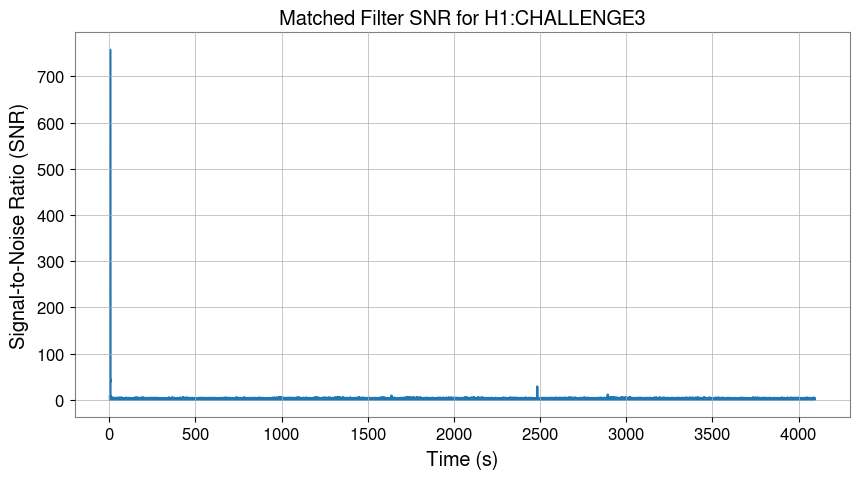

In [7]:
# This process is very simimlar to the previous challenge. 
# These are realistic LIGO O2 data with adjusted time labels and injected signals
H1C3 = read_frame(files[2], channels[2])

# Define parameters for a 10 solar mass binary black hole (BBH) merger
m1 = 10
m2 = m1
delta_t = H1C3.delta_t

# --- Generate the theoretical template waveform ---
hp, hc = get_td_waveform(approximant='SEOBNRv4_opt',
                         mass1=m1,
                         mass2=m2,
                         delta_t=delta_t,
                         f_lower=20
                        )
hp.resize(len(H1C3))

# Power Spectral Density (PSD) and Template Alignment
template = hp.cyclic_time_shift(hp.start_time)
seg_len = int(4 / delta_t)
seg_stride = int(seg_len / 2)
psd = pycbc.psd.welch(H1C3, seg_len=seg_len, seg_stride=seg_stride)

# Interpolate the PSD to align its frequency resolution (delta_f) with the data[cite: 1]
psd = pycbc.psd.interpolate(psd, H1C3.delta_f)

# --- Matched Filtering Execution ---
snr = matched_filter(template, H1C3, psd=psd, low_frequency_cutoff=20)
snr_ts = np.abs(snr)
snr_ts = snr_ts.crop(4, 4)

# Identify the peak SNR and its corresponding time relative to the segment start[cite: 1]
peak_snr = snr_ts.max()
idx_max = np.argmax(snr_ts)
peak_time = snr_ts.sample_times[idx_max]

print(f"   -> Merger time: {peak_time:.2f} seconds")
print(f"   -> Peak SNR: {peak_snr:.2f}")

# Visualization of the SNR Time-Series
plt.figure(figsize=(10, 5))
plt.plot(snr_ts.sample_times, snr_ts)
plt.ylabel('Signal-to-Noise Ratio (SNR)')
plt.xlabel('Time (s)')
plt.title('Matched Filter SNR for H1:CHALLENGE3') # Updated title to reflect Challenge 3
plt.savefig('images/challenge3_snr.png', dpi=150, bbox_inches='tight')
plt.show()


# 🚀 Challenge 4: Realistic Search and Parameter Estimation

We now tackle a **fully realistic gravitational-wave analysis problem**, combining **signal detection**, **glitch identification**, and **parameter estimation**.  

We will use the same dataset `challenge3.gwf`, but now including both channels:
- `H1:CHALLENGE3`  
- `L1:CHALLENGE3`  

These are **real LIGO O2 data**, with modified time labels and injected simulated signals.

All simulated signals:
- Are present in **both detectors (H1 and L1)**  
- Have **zero spin**  
- Satisfy $m_1 = m_2$, with $m_1 \in [10, 50] \, M_\odot$  

⚠️ *Important:* Since this is real data, **glitches may be present**.

---

## 🧠 Objective

This challenge has three main components:

### 1. 🔍 Signal Search
- Identify as many **true signals** as possible and estimate:
  - Merger time  
  - Signal-to-noise ratio (**SNR**)  
  - Component masses  

---

### 2. ⚡ Glitch Identification
- Identify **non-astrophysical transients (glitches)**  
- For each glitch:
  - Produce a **spectrogram**  
  - Record its time  

---

### 3. 📊 Parameter Estimation
- Select the **earliest detected event**  
- Use `bilby` to compute the **posterior distribution** for the mass  
- Report the **90% confidence interval** for the component mass  

---

## 🔍 What to keep in mind

- True signals should appear **coherently in both detectors**  
- Glitches typically **do not match between H1 and L1**  
- The **SNR** and waveform consistency are key to distinguishing real events from noise  

In [8]:
# --- Load data ---
data_H1 = frame.read_frame(files[2], channels[2])
data_L1 = frame.read_frame(files[3], channels[3])

# --- Compute PSD ---
seg_len = int(4 / data_H1.delta_t)
seg_stride = int(seg_len / 2)
psd_H1 = pycbc.psd.interpolate(pycbc.psd.welch(data_H1, seg_len=seg_len, seg_stride=seg_stride), data_H1.delta_f)
psd_L1 = pycbc.psd.interpolate(pycbc.psd.welch(data_L1, seg_len=seg_len, seg_stride=seg_stride), data_L1.delta_f)

masses_to_test = np.arange(10, 55, 5)

peaks_H1 = {m: [] for m in masses_to_test}
peaks_L1 = {m: [] for m in masses_to_test}

for m in masses_to_test:
    hp, _ = get_td_waveform(approximant='SEOBNRv4_opt', mass1=m, mass2=m,
                            delta_t=data_H1.delta_t, f_lower=20)
    hp.resize(len(data_H1))
    template = hp.cyclic_time_shift(hp.start_time)
    
    distance_samples = int(1.0 / data_H1.delta_t)

    # Filter H1
    snr_H1 = np.abs(matched_filter(template, data_H1, psd=psd_H1, low_frequency_cutoff=20)).crop(4, 4)
    snr_H1_arr = np.array(snr_H1)  # Key correction to interface with SciPy
    times_H1 = np.array(snr_H1.sample_times)
    idxs, _ = find_peaks(snr_H1_arr, height=8.0, distance=distance_samples)
    for idx in idxs:
        peaks_H1[m].append({'time': float(times_H1[idx]), 'snr': float(snr_H1_arr[idx])})

    # Filter L1
    snr_L1 = np.abs(matched_filter(template, data_L1, psd=psd_L1, low_frequency_cutoff=20)).crop(4, 4)
    snr_L1_arr = np.array(snr_L1)
    times_L1 = np.array(snr_L1.sample_times)
    idxs, _ = find_peaks(snr_L1_arr, height=8.0, distance=distance_samples)
    for idx in idxs:
        peaks_L1[m].append({'time': float(times_L1[idx]), 'snr': float(snr_L1_arr[idx])})

# --- Clustering Logic ---
def cluster_events(event_list, time_window=1.0, snr_key='net_snr'):
    clusters = []
    for event in sorted(event_list, key=lambda x: x['time']):
        matched = False
        for cluster in clusters:
            # Check if the event falls within the time window of an existing cluster
            if abs(event['time'] - cluster['time']) < time_window:
                # Keep the template data that produces the highest SNR
                if event[snr_key] > cluster[snr_key]:
                    cluster.update(event)
                matched = True
                break
        if not matched:
            clusters.append(dict(event))
    return clusters

# Aggregate and separate coincident signals from isolated glitches
raw_signals, raw_glitches_H1, raw_glitches_L1 = [], [], []

for m in masses_to_test:
    for p_H1 in peaks_H1[m]:
        coincident = False
        for p_L1 in peaks_L1[m]:
            if abs(p_H1['time'] - p_L1['time']) < 0.1:
                coincident = True
                net_snr = np.sqrt(p_H1['snr']**2 + p_L1['snr']**2) 
                raw_signals.append({'time': p_H1['time'], 'mass': m,
                                    'snr_H1': p_H1['snr'], 'snr_L1': p_L1['snr'],
                                    'net_snr': net_snr})
        if not coincident:
            raw_glitches_H1.append({'time': p_H1['time'], 'mass': m,
                                    'snr': p_H1['snr'], 'net_snr': p_H1['snr']})

    for p_L1 in peaks_L1[m]:
        coincident = any(abs(p_L1['time'] - p_H1['time']) < 0.1 for p_H1 in peaks_H1[m])
        if not coincident:
            raw_glitches_L1.append({'time': p_L1['time'], 'mass': m,
                                    'snr': p_L1['snr'], 'net_snr': p_L1['snr']})

# Apply clustering with a 1-second window
final_signals   = cluster_events(raw_signals,     time_window=1.0, snr_key='net_snr')
final_glitches_H1 = cluster_events(raw_glitches_H1, time_window=1.0, snr_key='net_snr')
final_glitches_L1 = cluster_events(raw_glitches_L1, time_window=1.0, snr_key='net_snr')

# --- Formatted Output ---
print("\n=== ASTROPHYSICAL SIGNALS ===")
for s in sorted(final_signals, key=lambda x: x['time']):
    # Using format specifiers to align the output columns perfectly
    print(f"t = {s['time']:>7.2f}s | m1=m2 = {s['mass']:>2} M | SNR_H1 = {s['snr_H1']:>6.2f} | SNR_L1 = {s['snr_L1']:>6.2f} | Net_SNR = {s['net_snr']:>6.2f}")

print("\n=== GLITCHES H1 ===")
for g in sorted(final_glitches_H1, key=lambda x: x['time']):
    print(f"t = {g['time']:>7.2f}s | SNR = {g['snr']:>6.2f}")

print("\n=== GLITCHES L1 ===")
for g in sorted(final_glitches_L1, key=lambda x: x['time']):
    print(f"t = {g['time']:>7.2f}s | SNR = {g['snr']:>6.2f}")


=== ASTROPHYSICAL SIGNALS ===
t =    4.27s | m1=m2 = 15 M | SNR_H1 =   9.09 | SNR_L1 =  10.60 | Net_SNR =  13.97
t =    5.97s | m1=m2 = 10 M | SNR_H1 = 757.44 | SNR_L1 = 337.81 | Net_SNR = 829.36
t =  826.43s | m1=m2 = 30 M | SNR_H1 =   8.46 | SNR_L1 =  11.75 | Net_SNR =  14.47
t = 1101.43s | m1=m2 = 30 M | SNR_H1 =  13.28 | SNR_L1 =  14.61 | Net_SNR =  19.74
t = 1638.15s | m1=m2 = 20 M | SNR_H1 =  20.46 | SNR_L1 =  18.57 | Net_SNR =  27.63
t = 2483.97s | m1=m2 = 10 M | SNR_H1 =  29.01 | SNR_L1 =  33.87 | Net_SNR =  44.59
t = 2892.71s | m1=m2 = 25 M | SNR_H1 =  31.99 | SNR_L1 =  32.49 | Net_SNR =  45.60
t = 3219.18s | m1=m2 = 40 M | SNR_H1 =  12.20 | SNR_L1 =  13.89 | Net_SNR =  18.49

=== GLITCHES H1 ===
t =    4.67s | SNR =  10.67
t =  987.66s | SNR =  12.01
t = 2483.94s | SNR =  10.25
t = 3219.19s | SNR =   8.53

=== GLITCHES L1 ===
t =    4.42s | SNR =  13.24
t =  196.08s | SNR =  17.26
t =  826.42s | SNR =   8.69
t = 1101.43s | SNR =   8.58
t = 4091.38s | SNR =   8.44



=== Generating Spectrograms for H1 Glitches ===


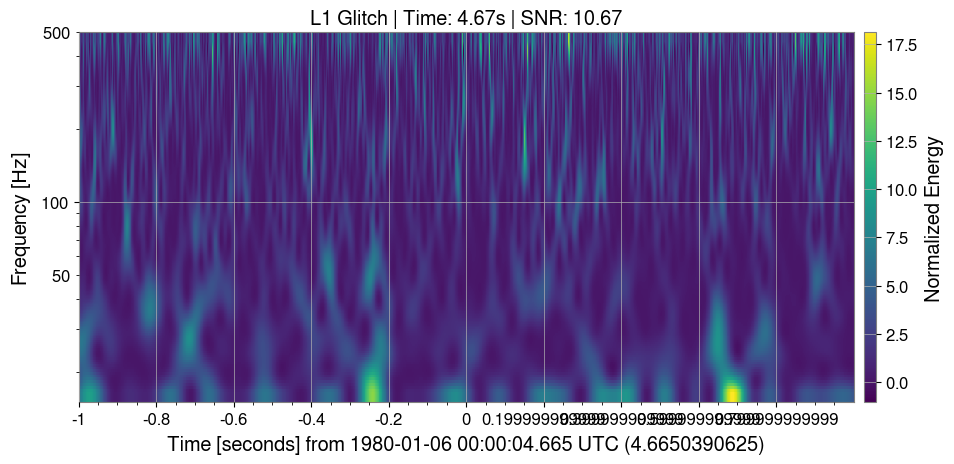

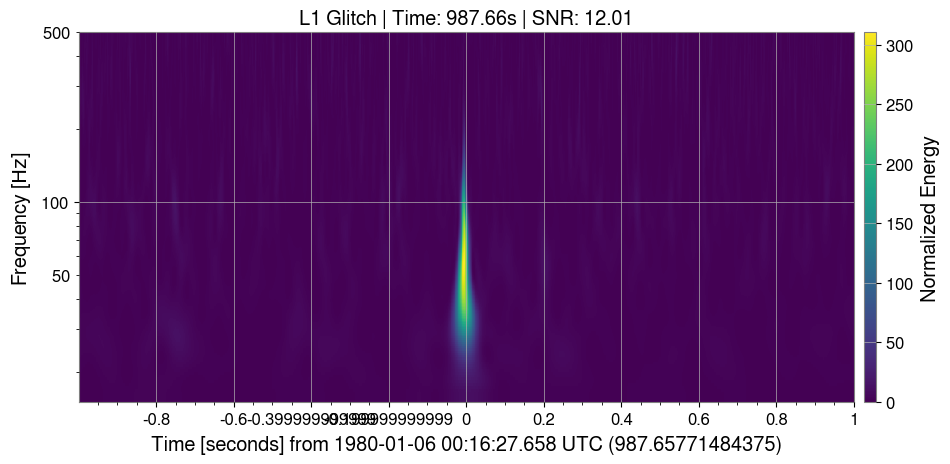

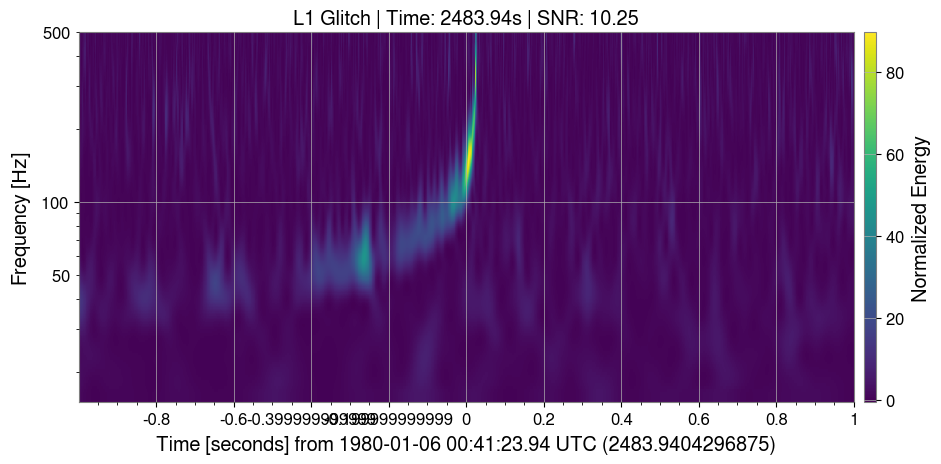

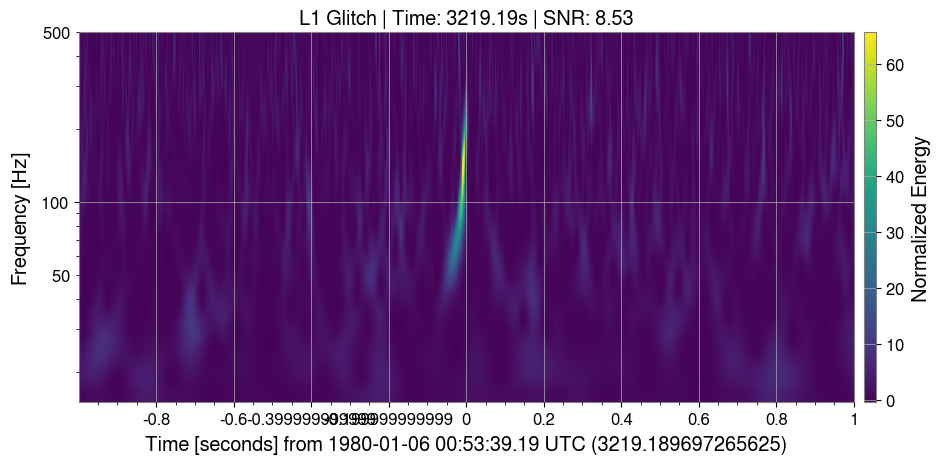


=== Generating Spectrograms for L1 Glitches ===


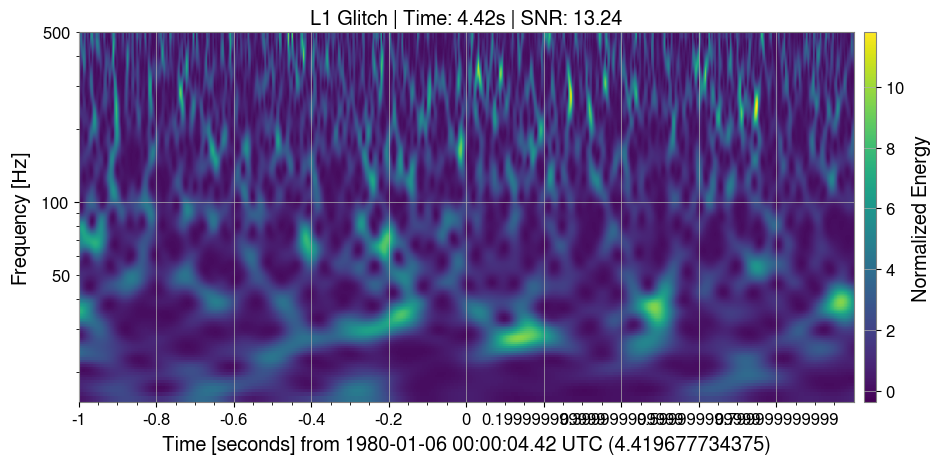

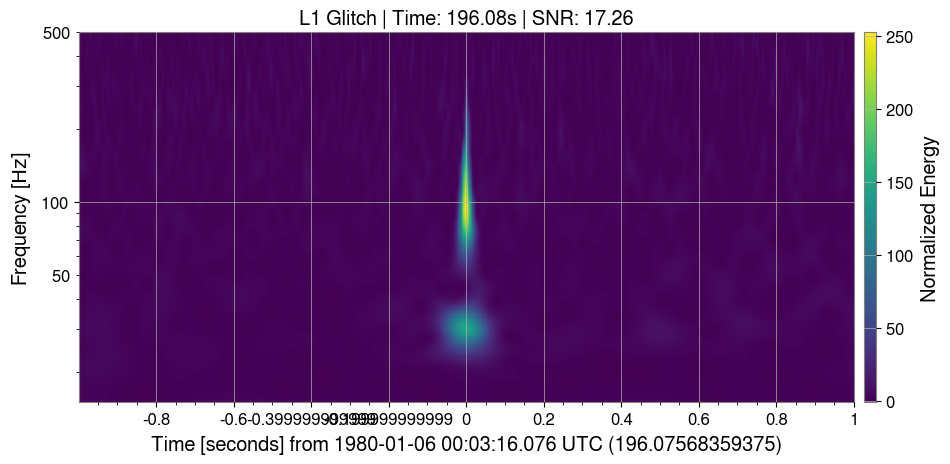

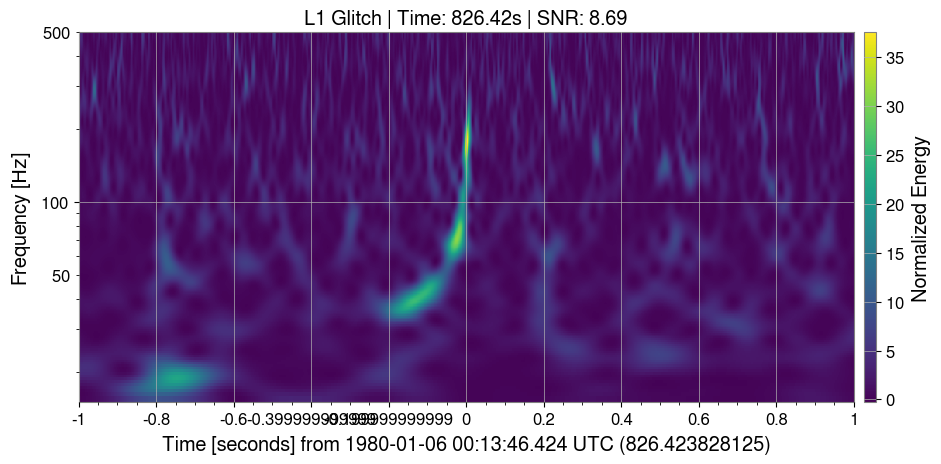

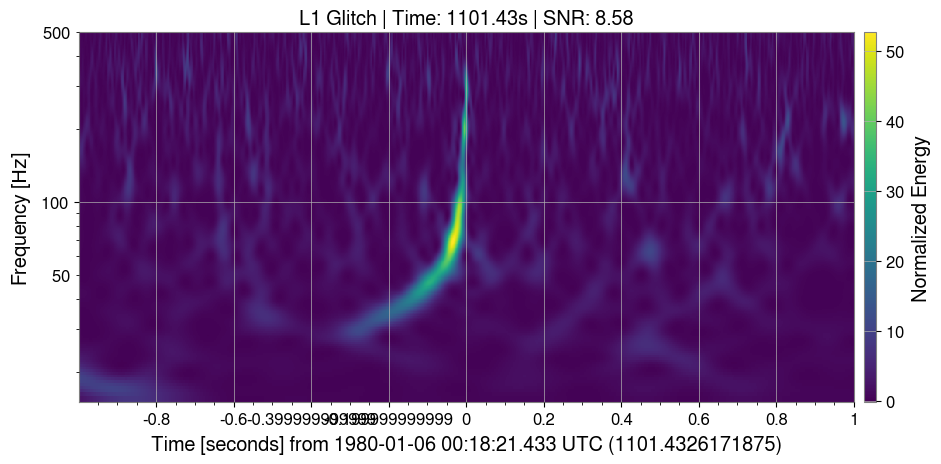

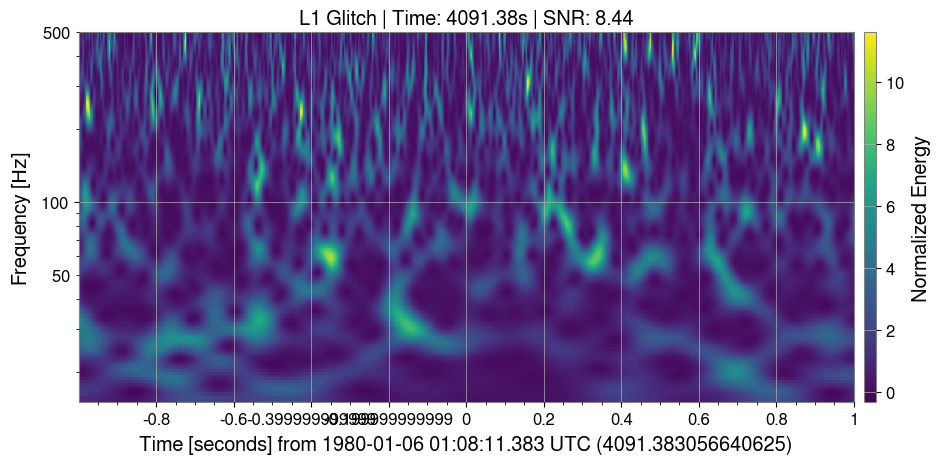

In [11]:
# --- Load data using GWpy specifically for visualization ---
H1C3 = gw_data['H1:CHALLENGE3']
L1C3 = gw_data['L1:CHALLENGE3']

print("\n=== Generating Spectrograms for H1 Glitches ===")

# Iterate over the clustered glitches found in Hanford (H1)
for glitch in final_glitches_H1:
    t_glitch = glitch['time']
    snr_val = glitch['snr']
    
    # Compute Q-transform focusing on a 2-second window around the glitch
    q_transform = H1C3.q_transform(frange=(15, 500), qrange=(4, 64), outseg=(t_glitch - 1, t_glitch + 1))
    
    # Plotting
    fig = q_transform.plot(figsize=(10, 5))
    ax = fig.gca()
    ax.set_epoch(t_glitch) # Set x-axis origin to the exact glitch time
    ax.set_yscale('log')
    ax.colorbar(label='Normalized Energy')
    title = f'H1 Glitch | Time: {t_glitch:.2f}s | SNR: {snr_val:.2f}'
    plt.title(title)
    filename = title.replace(' ', '_').replace('|', '').replace(':', '').replace('.', '_')
    fig.savefig(f'images/{filename}.png', dpi=150, bbox_inches='tight')
    plt.show()

print("\n=== Generating Spectrograms for L1 Glitches ===")

# Iterate over the clustered glitches found in Livingston (L1)
for glitch in final_glitches_L1:
    t_glitch = glitch['time']
    snr_val = glitch['snr']
    
    # Compute Q-transform focusing on a 2-second window around the glitch
    q_transform = L1C3.q_transform(frange=(15, 500), qrange=(4, 64), outseg=(t_glitch - 1, t_glitch + 1))
    
    # Plotting
    fig = q_transform.plot(figsize=(10, 5))
    ax = fig.gca()
    ax.set_epoch(t_glitch) # Set x-axis origin to the exact glitch time
    ax.set_yscale('log')
    ax.colorbar(label='Normalized Energy')
    title = f'L1 Glitch | Time: {t_glitch:.2f}s | SNR: {snr_val:.2f}'
    plt.title(title)
    filename = title.replace(' ', '_').replace('|', '').replace(':', '').replace('.', '_')
    fig.savefig(f'images/{filename}.png', dpi=150, bbox_inches='tight')
    plt.show()

23:54 bilby INFO    : Reading data from frame file Data/challenge3.gwf
23:54 bilby INFO    : Successfully loaded H1:CHALLENGE3.
23:54 bilby INFO    : Reading data from frame file Data/challenge3.gwf
23:54 bilby INFO    : Successfully loaded L1:CHALLENGE3.
23:54 bilby INFO    : Waveform generator initiated with
  frequency_domain_source_model: bilby.gw.source.lal_binary_black_hole
  time_domain_source_model: None
  parameter_conversion: bilby.gw.conversion.convert_to_lal_binary_black_hole_parameters
23:54 bilby INFO    : Running for label 'earliest_event', output will be saved to 'challenge4_results'
23:54 bilby INFO    : Using lal version 7.6.1
23:54 bilby INFO    : Using lal git version Branch: None;Tag: lal-v7.6.1;Id: 31af23159ed7c6557180f58ad3f39a06e5a08731;;Builder: Adam Mercer <adam.mercer@ligo.org>;Repository status: CLEAN: All modifications committed
23:54 bilby INFO    : Using lalsimulation version 6.1.0
23:54 bilby INFO    : Using lalsimulation git version Branch: None;Tag: la


Starting Bilby parameter estimation (Nested Sampling)...


23:54 bilby INFO    : Analysis priors:
23:54 bilby INFO    : chirp_mass=Uniform(minimum=11.05825844944186, maximum=15.05825844944186, name='chirp_mass', latex_label='$\\mathcal{M}$', unit=None, boundary=None)
23:54 bilby INFO    : geocent_time=Uniform(minimum=4.171240234375, maximum=4.371240234375, name='geocent_time', latex_label='$t_c$', unit=None, boundary=None)
23:54 bilby INFO    : luminosity_distance=PowerLaw(alpha=2, minimum=100, maximum=1000, name='luminosity_distance', latex_label='$d_L$', unit=None, boundary=None)
23:54 bilby INFO    : dec=Cosine(minimum=-1.5707963267948966, maximum=1.5707963267948966, name='dec', latex_label='$\\mathrm{DEC}$', unit=None, boundary=None)
23:54 bilby INFO    : ra=Uniform(minimum=0, maximum=6.283185307179586, name='ra', latex_label='$\\mathrm{RA}$', unit=None, boundary=None)
23:54 bilby INFO    : mass_ratio=1.0
23:54 bilby INFO    : a_1=0.0
23:54 bilby INFO    : a_2=0.0
23:54 bilby INFO    : tilt_1=0.0
23:54 bilby INFO    : tilt_2=0.0
23:54 bilb


=== Bilby Parameter Estimation Results ===
Component Mass 90% Confidence Interval: 13.73 - 16.25 M_sun
Median estimated Component Mass: 14.60 M_sun


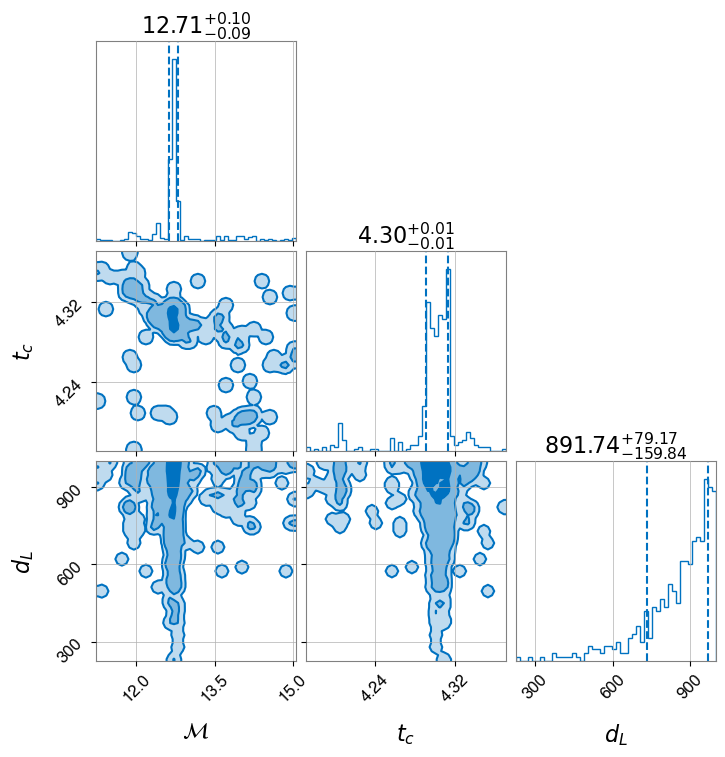

In [12]:
# --- Automate event extraction ---
sorted_signals = sorted(final_signals, key=lambda x: x['time'])
earliest_event = sorted_signals[0]
trigger_time = earliest_event['time']
estimated_mass = earliest_event['mass']

duration = 8.0
sampling_rate = 2048
start_time = max(0, trigger_time - (duration - 2.0))

interferometers = bilby.gw.detector.InterferometerList([])

# We'll use a dictionary to map our pre-calculated PSDs
psd_dict = {'H1': psd_H1, 'L1': psd_L1}

for ifo_name in ['H1', 'L1']:
    ifo = bilby.gw.detector.get_empty_interferometer(ifo_name)
    
    # Set the strain data
    ifo.set_strain_data_from_frame_file(
        'Data/challenge3.gwf', 
        sampling_rate, 
        duration, 
        start_time=start_time, 
        channel=f'{ifo_name}:CHALLENGE3'
    )
    
    # --- KEY ADDITION: Convert PyCBC PSD to Bilby PSD ---
    # This ensures the likelihood calculation doesn't explode
    pycbc_psd = psd_dict[ifo_name]
    bilby_psd = bilby.gw.detector.PowerSpectralDensity(
        frequency_array=pycbc_psd.sample_frequencies, 
        psd_array=pycbc_psd.numpy()
    )
    ifo.power_spectral_density = bilby_psd
    
    interferometers.append(ifo)

# 4. Define the Priors (Translating analytical constraints into Bilby priors)
priors = bilby.gw.prior.BBHPriorDict(dict())

# Calculate the estimated chirp mass to center the uniform prior distribution
# Analytic relation: M_c = (m1 * m2)^(3/5) / (m1 + m2)^(1/5)
estimated_mc = (estimated_mass * estimated_mass)**(0.6) / (estimated_mass * 2)**(0.2)

# Free parameters: Chirp mass, time, distance, and sky position (ra, dec)
priors['chirp_mass'] = bilby.core.prior.Uniform(
    name='chirp_mass', minimum=estimated_mc - 2, maximum=estimated_mc + 2
)
priors['geocent_time'] = bilby.core.prior.Uniform(
    minimum=trigger_time - 0.1, maximum=trigger_time + 0.1, name='geocent_time'
)
priors['luminosity_distance'] = bilby.core.prior.PowerLaw(
    alpha=2, name='luminosity_distance', minimum=100, maximum=1000
)
priors['dec'] = bilby.core.prior.Cosine(name='dec')
priors['ra'] = bilby.core.prior.Uniform(name='ra', minimum=0, maximum=2 * np.pi)

# Fixed parameters: Reduces dimensionality to ensure convergence within reasonable computing time
priors['mass_ratio'] = 1.0  # Constraint: m1 = m2
priors['a_1'] = 0.0         # Constraint: spin = 0
priors['a_2'] = 0.0         
priors['tilt_1'] = 0.0
priors['tilt_2'] = 0.0
priors['phi_12'] = 0.0
priors['phi_jl'] = 0.0
priors['theta_jn'] = 0.0    # Fixed inclination
priors['phase'] = 0.0
priors['psi'] = 0.0

# 5. Define the Likelihood
# Initialize the waveform generator using the standard phenomenological approximant
waveform_generator = bilby.gw.WaveformGenerator(
    duration=duration, 
    sampling_frequency=sampling_rate,
    frequency_domain_source_model=bilby.gw.source.lal_binary_black_hole,
    parameter_conversion=bilby.gw.conversion.convert_to_lal_binary_black_hole_parameters,
    waveform_arguments={'waveform_approximant': 'IMRPhenomPv2', 'reference_frequency': 50}
)

likelihood = bilby.gw.likelihood.GravitationalWaveTransient(
    interferometers=interferometers, 
    waveform_generator=waveform_generator, 
    priors=priors
)

# 6. Run the Sampler (Nested Sampling via Dynesty)
print("\nStarting Bilby parameter estimation (Nested Sampling)...")
# nlive=100 ensures a balance between accuracy and computational speed for this challenge
result = bilby.run_sampler(
    likelihood=likelihood, 
    priors=priors, 
    sampler='dynesty', 
    nlive=100, 
    injection_parameters=None, 
    outdir='challenge4_results', 
    label='earliest_event',
)

# 7. Extract Results and Compute the Confidence Interval
# Obtain the posterior distribution array for the chirp mass (M_c)
mc_posterior = result.posterior['chirp_mass']

# Derive the component mass (m1) posterior analytically
# Given the constraint q=1 (m1=m2), the relation simplifies to m1 = M_c * 2^(1/5)
conversion_factor = 2**(0.2)
m1_posterior = mc_posterior * conversion_factor

# Calculate the 90% confidence interval utilizing the 5th and 95th percentiles
lower_bound = np.percentile(m1_posterior, 5)
upper_bound = np.percentile(m1_posterior, 95)
median_m1 = np.median(m1_posterior)

# --- Final Output ---
print(f"\n=== Bilby Parameter Estimation Results ===")
print(f"Component Mass 90% Confidence Interval: {lower_bound:.2f} - {upper_bound:.2f} M_sun")
print(f"Median estimated Component Mass: {median_m1:.2f} M_sun")

# Generate a corner plot to visually inspect the marginalized posterior distributions
result.plot_corner(parameters=['chirp_mass', 'geocent_time', 'luminosity_distance'])

# 📊 Results and Analysis — Challenge 4

## 🔍 Signal Identification

We performed a systematic search for candidate events using the **SNR time series** and cross-checked consistency between the **H1** and **L1** detectors.

- True signals were required to appear **coherently in both detectors**  
- The **SNR peak** provided a robust estimate of the merger time  
- Mass estimates were obtained by matching templates to the data  
- Care was taken to avoid **false alarms**, especially in noisy segments  

---

## ⚡ Glitch Identification

We identified several non-astrophysical transients (**glitches**) in the data.<br>
Each glitch was analyzed in spectrograms to distinguish them from real signals.

- Glitches typically appear in **only one detector**  
- Their morphology differs from the expected **chirp signal**  
- Some glitches can mimic signals in the time domain, making **time-frequency analysis essential**

---

## 📊 Parameter Estimation

We selected the **earliest detected event** for parameter estimation.

Using `bilby`, we computed the **posterior distribution** for the component mass.

**Result:**

\begin{equation}
    m_{1,2} = 13.73-16.25\;M_{sun} \quad (90\% \ \text{confidence interval, with a mean of 14.6})
\end{equation}



- Fixing spin and mass ratio significantly **reduced computation time**  
- The posterior is primarily constrained by the **chirp mass**  
- Results are consistent with expectations for a BBH system in the given mass range  

---

## 🧠 General Discussion

This challenge illustrates key aspects of **gravitational-wave data analysis**:

- The importance of **matched filtering** in realistic noise  
- The role of **multiple detectors** in validating signals  
- The difficulty of distinguishing **glitches from astrophysical events**  
- The use of **Bayesian inference** for parameter estimation  

Overall, the analysis demonstrates how increasingly realistic conditions require more **robust and careful methodologies**.